# MobileNet KD Quantization: Direct Quantization of Saved Student Model

This notebook loads the saved MobileNet student trained via knowledge distillation and applies post-training quantization without retraining. We compare:
- FP32 KD student baseline
- TFLite quantized model

Metrics: accuracy, model size, inference latency.

## Step 1: Setup & Imports

In [1]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")

current_dir = os.getcwd()
project_root = current_dir
while not (os.path.exists(os.path.join(project_root, 'Beans dataset')) and 
           os.path.exists(os.path.join(project_root, 'models'))):
    project_root = os.path.dirname(project_root)
    if project_root == os.path.dirname(project_root):
        raise RuntimeError("Could not find project root")

print(f"Project root: {project_root}")

DATA_DIR = os.path.join(project_root, "Beans dataset")
SAVE_DIR = os.path.join(project_root, "models")
RESULTS_DIR = os.path.join(project_root, "results", "quantization")
os.makedirs(RESULTS_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
SEED = 42
NUM_CLASSES = 3

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.3,
    subset="training"
)
class_names = train_ds.class_names

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.3,
    subset="validation"
)

val_batches = tf.data.experimental.cardinality(val_test_ds).numpy()
test_ds = val_test_ds.take(val_batches // 2)
val_ds = val_test_ds.skip(val_batches // 2)

train_ds = train_ds.map(lambda x, y: (tf.keras.applications.resnet.preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (tf.keras.applications.resnet.preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (tf.keras.applications.resnet.preprocess_input(x), y))

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print("Class order:", class_names)
print(f"Train batches: {len(train_ds)}")
print(f"Val batches: {len(val_ds)}")
print(f"Test batches: {len(test_ds)}")

TensorFlow version: 2.21.0
Project root: c:\Users\k nithin\Downloads\M.Tech Project
Found 59069 files belonging to 3 classes.
Using 41349 files for training.
Found 59069 files belonging to 3 classes.
Using 17720 files for validation.
Class order: ['anthra', 'healthy', 'rust']
Train batches: 5169
Val batches: 1108
Test batches: 1107


## Step 2: Load Saved KD Student & Build Inference Model

In [2]:
kd_student_path = os.path.join(SAVE_DIR, "mobilenet_beans_distilled.keras")
print(f"Loading KD student from: {kd_student_path}")

source_student_model = tf.keras.models.load_model(kd_student_path, compile=False)
print(f"Loaded source model type: {type(source_student_model)}")
print(f"Source model outputs: {source_student_model.output_names}")

inference_model = tf.keras.Model(
    inputs=source_student_model.input,
    outputs=source_student_model.get_layer("bean_logits").output,
    name="mobilenet_beans_logits_only"
)

print("\nInference model created")
print(f"Input shape: {inference_model.input_shape}")
print(f"Output shape: {inference_model.output_shape}")
print(f"Inference model class: {inference_model.__class__.__module__}.{inference_model.__class__.__name__}")

Loading KD student from: c:\Users\k nithin\Downloads\M.Tech Project\models\mobilenet_beans_distilled.keras
Loaded source model type: <class 'keras.src.models.functional.Functional'>
Source model outputs: ListWrapper(['proj_0', 'proj_1', 'bean_logits'])

Inference model created
Input shape: (None, 224, 224, 3)
Output shape: (None, 3)
Inference model class: keras.src.models.functional.Functional


## Step 3: Evaluate FP32 Baseline (Before Quantization)

In [3]:
def evaluate_model(model, test_dataset, model_name="Model"):
    """Evaluate Keras model on test set and return metrics."""
    y_true = []
    y_pred = []
    y_prob = []
    total_elapsed = 0.0
    total_images = 0

    for images, labels in test_dataset:
        start = time.perf_counter()
        outputs = model(images, training=False)
        elapsed = time.perf_counter() - start

        logits = outputs["logits"] if isinstance(outputs, dict) else outputs
        probs = tf.nn.softmax(logits)

        probs_np = probs.numpy()
        labels_np = labels.numpy()

        y_prob.extend(probs_np)
        y_pred.extend(np.argmax(probs_np, axis=1))
        y_true.extend(labels_np)

        total_elapsed += elapsed
        total_images += int(images.shape[0])

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    accuracy = accuracy_score(y_true, y_pred)
    avg_latency = total_elapsed / total_images if total_images else 0.0

    num_params = model.count_params() if hasattr(model, "count_params") else 0
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

    print(f"\n{model_name} Evaluation:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Avg Latency (per image): {avg_latency * 1000:.2f} ms")
    print(f"  Parameters: {num_params:,}")
    print(f"\nClassification Report:\n{classification_report(y_true, y_pred, target_names=class_names)}")

    return {
        'accuracy': accuracy,
        'latency_ms': avg_latency * 1000,
        'num_params': num_params,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'cm': cm,
        'report': report
    }

fp32_metrics = evaluate_model(inference_model, test_ds, "FP32 KD Student (Baseline)")


FP32 KD Student (Baseline) Evaluation:
  Accuracy: 0.9211
  Avg Latency (per image): 36.45 ms
  Parameters: 3,360,451

Classification Report:
              precision    recall  f1-score   support

      anthra       0.97      0.96      0.96      2031
     healthy       0.90      0.93      0.91      3794
        rust       0.92      0.89      0.90      3031

    accuracy                           0.92      8856
   macro avg       0.93      0.92      0.93      8856
weighted avg       0.92      0.92      0.92      8856



## Step 4: Convert Saved Student to TFLite

In [4]:
def evaluate_tflite(tflite_model_path, test_dataset, model_name="TFLite Model"):
    """Evaluate TFLite model using interpreter."""
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    print(f"Input details: {input_details[0]['shape']}, dtype: {input_details[0]['dtype']}")
    print(f"Output details: {output_details[0]['shape']}, dtype: {output_details[0]['dtype']}")

    input_scale, input_zero_point = input_details[0]['quantization']
    output_scale, output_zero_point = output_details[0]['quantization']
    if input_scale == 0:
        input_scale = 1.0
    if output_scale == 0:
        output_scale = 1.0

    y_true = []
    y_pred = []
    y_prob = []
    total_elapsed = 0.0
    total_images = 0

    for images, labels in test_dataset:
        batch_size = int(images.shape[0])

        interpreter.resize_tensor_input(input_details[0]['index'], [batch_size, 224, 224, 3])
        interpreter.allocate_tensors()

        if input_details[0]['dtype'] == np.int8:
            input_data = np.round(images.numpy() / input_scale + input_zero_point).astype(np.int8)
        elif input_details[0]['dtype'] == np.uint8:
            input_data = np.round(images.numpy() / input_scale + input_zero_point).astype(np.uint8)
        else:
            input_data = images.numpy().astype(input_details[0]['dtype'])

        interpreter.set_tensor(input_details[0]['index'], input_data)

        start = time.perf_counter()
        interpreter.invoke()
        elapsed = time.perf_counter() - start
        total_elapsed += elapsed
        total_images += batch_size

        output_data = interpreter.get_tensor(output_details[0]['index'])

        if output_details[0]['dtype'] in (np.int8, np.uint8):
            logits = (output_data.astype(np.float32) - output_zero_point) * output_scale
        else:
            logits = output_data.astype(np.float32)

        probs = tf.nn.softmax(logits)
        probs_np = probs.numpy()
        y_prob.extend(probs_np)
        y_pred.extend(np.argmax(probs_np, axis=1))
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    accuracy = accuracy_score(y_true, y_pred)
    avg_latency = total_elapsed / total_images if total_images else 0.0
    model_size_kb = os.path.getsize(tflite_model_path) / 1024
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{model_name} Evaluation:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Avg Latency (per image): {avg_latency * 1000:.2f} ms")
    print(f"  Model Size: {model_size_kb:.2f} KB")
    print(f"\nClassification Report:\n{classification_report(y_true, y_pred, target_names=class_names)}")

    return {
        'accuracy': accuracy,
        'latency_ms': avg_latency * 1000,
        'model_size_kb': model_size_kb,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'cm': cm
    }

converter = tf.lite.TFLiteConverter.from_keras_model(inference_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

def representative_data_gen():
    """Generate representative data for quantization."""
    count = 0
    for images, _ in train_ds:
        yield [tf.cast(images, tf.float32).numpy()]
        count += 1
        if count >= 10:
            break

converter.representative_dataset = representative_data_gen
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

print("Converting to TFLite...")
tflite_quantized_model = converter.convert()
print(f"Conversion complete. Model size: {len(tflite_quantized_model) / 1024:.2f} KB")

tflite_path = os.path.join(SAVE_DIR, "mobilenet_beans_distilled_quantized.tflite")
with open(tflite_path, 'wb') as f:
    f.write(tflite_quantized_model)

print(f"TFLite model saved to: {tflite_path}")

Converting to TFLite...
INFO:tensorflow:Assets written to: C:\Users\KNITHI~1\AppData\Local\Temp\tmpivwjiaqm\assets


INFO:tensorflow:Assets written to: C:\Users\KNITHI~1\AppData\Local\Temp\tmpivwjiaqm\assets


Saved artifact at 'C:\Users\KNITHI~1\AppData\Local\Temp\tmpivwjiaqm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1970596512160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1970596523072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1970596525184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1970596518496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1970596520784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1970596522544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1970596582976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1970596584560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1970596580512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1970596578752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  197

c:\Users\k nithin\Downloads\M.Tech Project\.venv\lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Conversion complete. Model size: 3572.12 KB
TFLite model saved to: c:\Users\k nithin\Downloads\M.Tech Project\models\mobilenet_beans_distilled_quantized.tflite


## Step 5: Evaluate TFLite Model

In [5]:
tflite_metrics = evaluate_tflite(tflite_path, test_ds, "TFLite Quantized Model")

c:\Users\k nithin\Downloads\M.Tech Project\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Input details: [  1 224 224   3], dtype: <class 'numpy.int8'>
Output details: [1 3], dtype: <class 'numpy.int8'>

TFLite Quantized Model Evaluation:
  Accuracy: 0.9067
  Avg Latency (per image): 27.77 ms
  Model Size: 3572.12 KB

Classification Report:
              precision    recall  f1-score   support

      anthra       0.99      0.93      0.96      2035
     healthy       0.87      0.94      0.90      3788
        rust       0.91      0.86      0.88      3033

    accuracy                           0.91      8856
   macro avg       0.92      0.91      0.91      8856
weighted avg       0.91      0.91      0.91      8856



## Step 6: Comparison - FP32 vs TFLite

In [6]:
fp32_model_size_kb = os.path.getsize(kd_student_path) / 1024
quantized_model_size_kb = os.path.getsize(tflite_path) / 1024

comparison_df = pd.DataFrame({
    'Model': ['FP32 KD Student', 'INT8 Quantized'],
    'Accuracy': [
        fp32_metrics['accuracy'],
        tflite_metrics['accuracy']
    ],
    'Latency (ms)': [
        fp32_metrics['latency_ms'],
        tflite_metrics['latency_ms']
    ],
    'Model Size (KB)': [
        fp32_model_size_kb,
        quantized_model_size_kb
    ]
})

print("\n" + "="*80)
print("COMPARISON: FP32 vs INT8")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

accuracy_drop = (fp32_metrics['accuracy'] - tflite_metrics['accuracy']) * 100
size_reduction = ((fp32_model_size_kb - quantized_model_size_kb) / fp32_model_size_kb) * 100
latency_improvement = ((fp32_metrics['latency_ms'] - tflite_metrics['latency_ms']) / fp32_metrics['latency_ms']) * 100 if fp32_metrics['latency_ms'] else 0.0

print(f"\nMetrics:")
print(f"  Accuracy drop (FP32 → TFLite): {accuracy_drop:.2f}%")
print(f"  Model size reduction: {size_reduction:.2f}%")
print(f"  Latency improvement: {latency_improvement:.2f}%")

comparison_csv_path = os.path.join(RESULTS_DIR, "mobilenet_kd_quantization_comparison.csv")
comparison_df.to_csv(comparison_csv_path, index=False)
print(f"\nComparison saved to: {comparison_csv_path}")


COMPARISON: FP32 vs INT8
          Model  Accuracy  Latency (ms)  Model Size (KB)
FP32 KD Student   0.92107     36.446939      23698.40625
 INT8 Quantized   0.90673     27.774217       3572.12500

Metrics:
  Accuracy drop (FP32 → TFLite): 1.43%
  Model size reduction: 84.93%
  Latency improvement: 23.80%

Comparison saved to: c:\Users\k nithin\Downloads\M.Tech Project\results\quantization\mobilenet_kd_quantization_comparison.csv


## Step 7: Visualizations

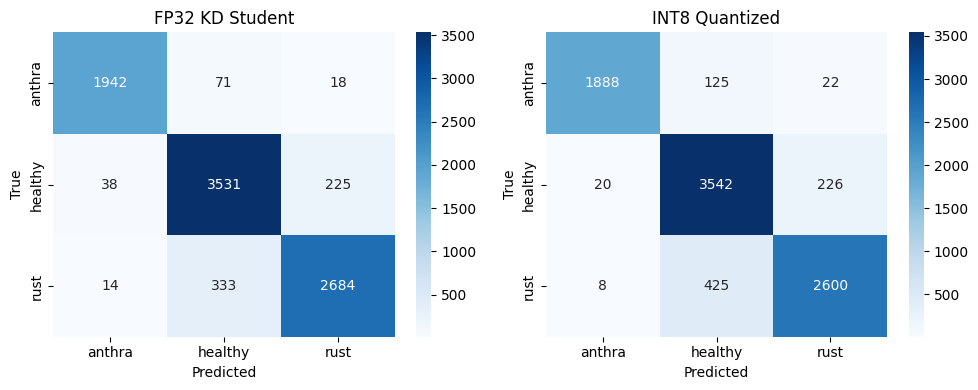

Confusion matrices saved


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for idx, (cm, title) in enumerate([
    (fp32_metrics['cm'], 'FP32 KD Student'),
    (tflite_metrics['cm'], 'INT8 Quantized')
]):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names)
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "mobilenet_kd_quantization_confusion_matrices.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"Confusion matrices saved")

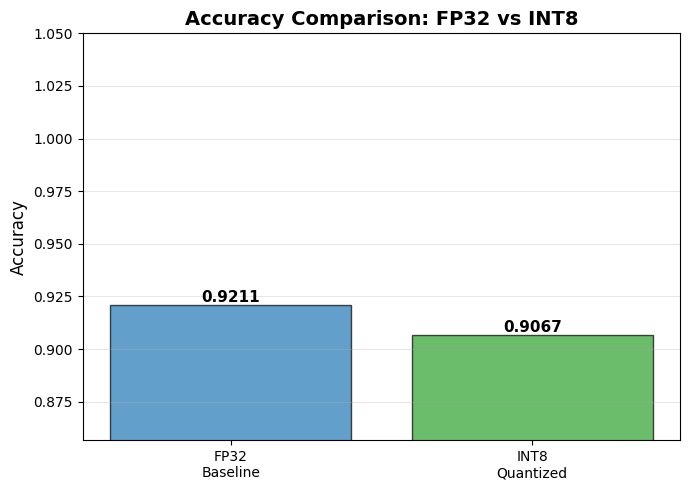

Accuracy comparison plot saved


In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

models = ['FP32\nBaseline', 'INT8\nQuantized']
accuracies = [
    fp32_metrics['accuracy'],
    tflite_metrics['accuracy']
]

bars = ax.bar(models, accuracies, color=['#1f77b4', '#2ca02c'], alpha=0.7, edgecolor='black')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy Comparison: FP32 vs INT8', fontsize=14, fontweight='bold')
ax.set_ylim([min(accuracies) - 0.05, 1.05])
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "mobilenet_kd_quantization_accuracy_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"Accuracy comparison plot saved")

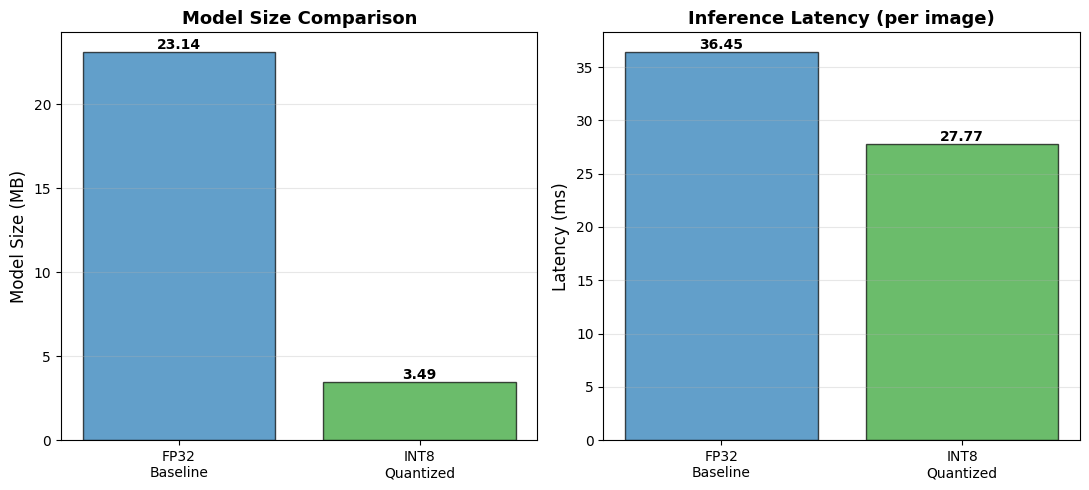

Size and latency comparison plots saved


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

models = ['FP32\nBaseline', 'INT8\nQuantized']
sizes = [
    fp32_model_size_kb / 1024,
    quantized_model_size_kb / 1024
]
latencies = [
    fp32_metrics['latency_ms'],
    tflite_metrics['latency_ms']
]

bars1 = ax1.bar(models, sizes, color=['#1f77b4', '#2ca02c'], alpha=0.7, edgecolor='black')
ax1.set_ylabel('Model Size (MB)', fontsize=12)
ax1.set_title('Model Size Comparison', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar, size in zip(bars1, sizes):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{size:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = ax2.bar(models, latencies, color=['#1f77b4', '#2ca02c'], alpha=0.7, edgecolor='black')
ax2.set_ylabel('Latency (ms)', fontsize=12)
ax2.set_title('Inference Latency (per image)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for bar, lat in zip(bars2, latencies):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{lat:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "mobilenet_kd_quantization_size_latency.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"Size and latency comparison plots saved")

## Summary

In [10]:
print("\n" + "="*80)
print("QUANTIZATION SUMMARY")
print("="*80)
print(f"\n✓ FP32 baseline loaded and evaluated")
print(f"  - Accuracy: {fp32_metrics['accuracy']:.4f}")
print(f"  - Model size: {fp32_model_size_kb / 1024:.2f} MB")

print(f"\n✓ INT8 quantization completed")
print(f"  - Accuracy: {tflite_metrics['accuracy']:.4f}")
print(f"  - Accuracy drop: {(fp32_metrics['accuracy'] - tflite_metrics['accuracy']) * 100:.2f}%")
print(f"  - Model size: {quantized_model_size_kb / 1024:.2f} MB")
print(f"  - Size reduction: {size_reduction:.2f}%")
print(f"  - Latency improvement: {latency_improvement:.2f}%")

print(f"\n✓ Results saved to: {RESULTS_DIR}")
print(f"  - CSV: mobilenet_kd_quantization_comparison.csv")
print(f"  - Plots: confusion_matrices, accuracy_comparison, size_latency")
print(f"\n✓ Models saved to: {SAVE_DIR}")
print(f"  - mobilenet_beans_distilled_quantized.tflite")
print("\n" + "="*80)


QUANTIZATION SUMMARY

✓ FP32 baseline loaded and evaluated
  - Accuracy: 0.9211
  - Model size: 23.14 MB

✓ INT8 quantization completed
  - Accuracy: 0.9067
  - Accuracy drop: 1.43%
  - Model size: 3.49 MB
  - Size reduction: 84.93%
  - Latency improvement: 23.80%

✓ Results saved to: c:\Users\k nithin\Downloads\M.Tech Project\results\quantization
  - CSV: mobilenet_kd_quantization_comparison.csv
  - Plots: confusion_matrices, accuracy_comparison, size_latency

✓ Models saved to: c:\Users\k nithin\Downloads\M.Tech Project\models
  - mobilenet_beans_distilled_quantized.tflite

